Dataset Shape: (569, 30)

Target Classes:
['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Training samples: 455
Testing samples: 114

===== Decision Tree Results =====
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix:
[[39  3]
 [ 4 68]]


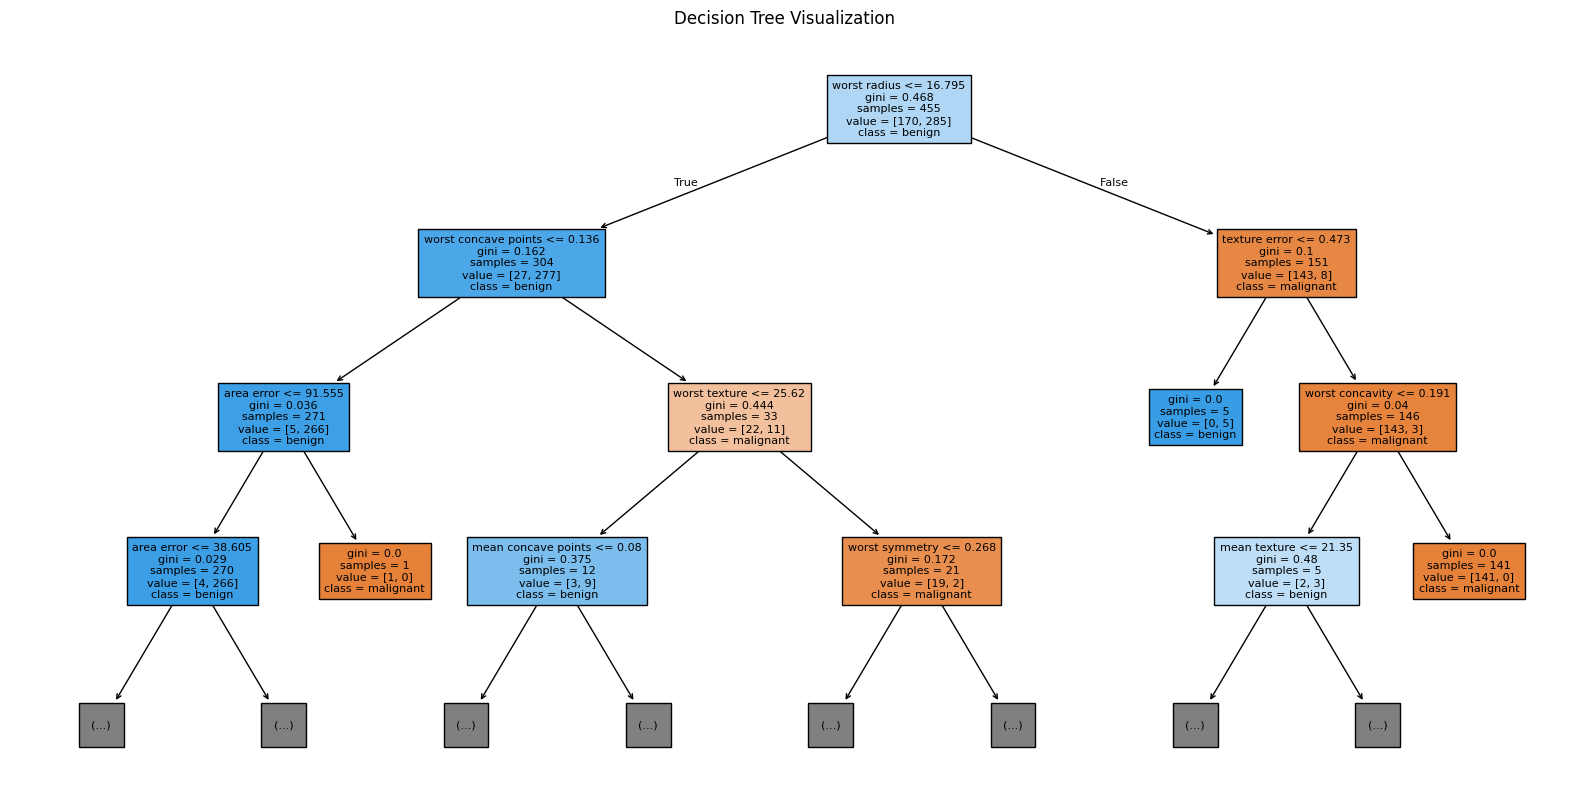


Top 10 Decision Tree Features:


,Feature,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000



===== Random Forest Results =====
Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[39  3]
 [ 2 70]]

Top 10 Random Forest Features:


,Feature,Importance
23,worst area,0.138294
27,worst concave points,0.132993
20,worst radius,0.100805
7,mean concave points,0.098489
22,worst perimeter,0.072224
2,mean perimeter,0.068612
0,mean radius,0.067465
6,mean concavity,0.057445
3,mean area,0.050615
26,worst concavity,0.031544



===== Model Comparison =====


,Model,Accuracy
0,Decision Tree,0.938596
1,Random Forest,0.956140


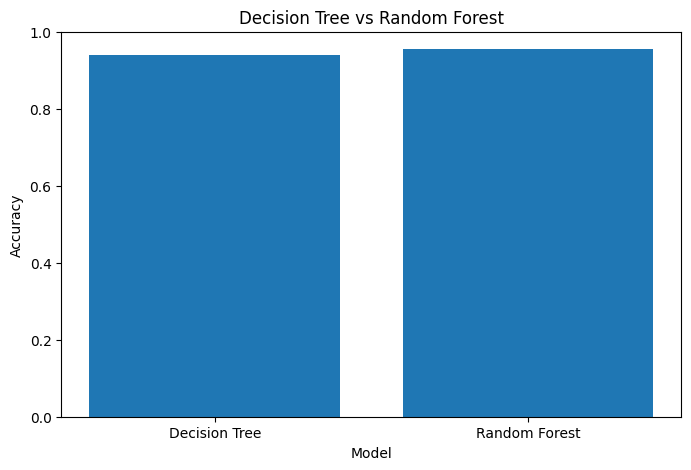

In [1]:
# W3D3: Decision Trees & Random Forests
# Decision Tree classification using Gini impurity
# and Random Forest comparison

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ---------------------------------------------------------
# 1. Load the dataset
# ---------------------------------------------------------

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print(data.target_names)

print("\nFirst 5 rows:")
display(X.head())

# ---------------------------------------------------------
# 2. Train-Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ---------------------------------------------------------
# 3. Train Decision Tree
# ---------------------------------------------------------

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

decision_tree.fit(X_train, y_train)

# Predictions
dt_pred = decision_tree.predict(X_test)

# ---------------------------------------------------------
# 4. Evaluate Decision Tree
# ---------------------------------------------------------

dt_accuracy = accuracy_score(y_test, dt_pred)

print("\n===== Decision Tree Results =====")
print("Accuracy:", round(dt_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=data.target_names
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

# ---------------------------------------------------------
# 5. Visualise Decision Tree
# ---------------------------------------------------------

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

# ---------------------------------------------------------
# 6. Feature Importance - Decision Tree
# ---------------------------------------------------------

dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Decision Tree Features:")
display(dt_importance.head(10))

# ---------------------------------------------------------
# 7. Train Random Forest
# ---------------------------------------------------------

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

random_forest.fit(X_train, y_train)

# Predictions
rf_pred = random_forest.predict(X_test)

# ---------------------------------------------------------
# 8. Evaluate Random Forest
# ---------------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n===== Random Forest Results =====")
print("Accuracy:", round(rf_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=data.target_names
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# ---------------------------------------------------------
# 9. Feature Importance - Random Forest
# ---------------------------------------------------------

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Random Forest Features:")
display(rf_importance.head(10))

# ---------------------------------------------------------
# 10. Compare Models
# ---------------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ]
})

print("\n===== Model Comparison =====")
display(results)

# ---------------------------------------------------------
# 11. Plot Model Comparison
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Decision Tree vs Random Forest")

plt.ylim(0, 1)
plt.show()